<a href="https://colab.research.google.com/github/fandri-indranata/data-science-2026/blob/main/Pertemuan5_FandriIndranata_230401010180.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama: Fandri Indranata NIM: 230401010180 Kelas: IF401

In [1]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# 1. LOAD & INSPECT DATASET
# Mengambil dataset penguins bawaan Seaborn
df = sns.load_dataset('penguins')

# Membersihkan missing values agar grafik tidak error
df = df.dropna()

print("=== Informasi Dataset ===")
print(f"Shape: {df.shape}")
print("\n=== Statistik Deskriptif ===")
print(df.describe().round(2))

=== Informasi Dataset ===
Shape: (333, 7)

=== Statistik Deskriptif ===
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


/tmp/ipykernel_3592/869992028.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='flipper_length_mm', palette='Set2', ax=ax3)


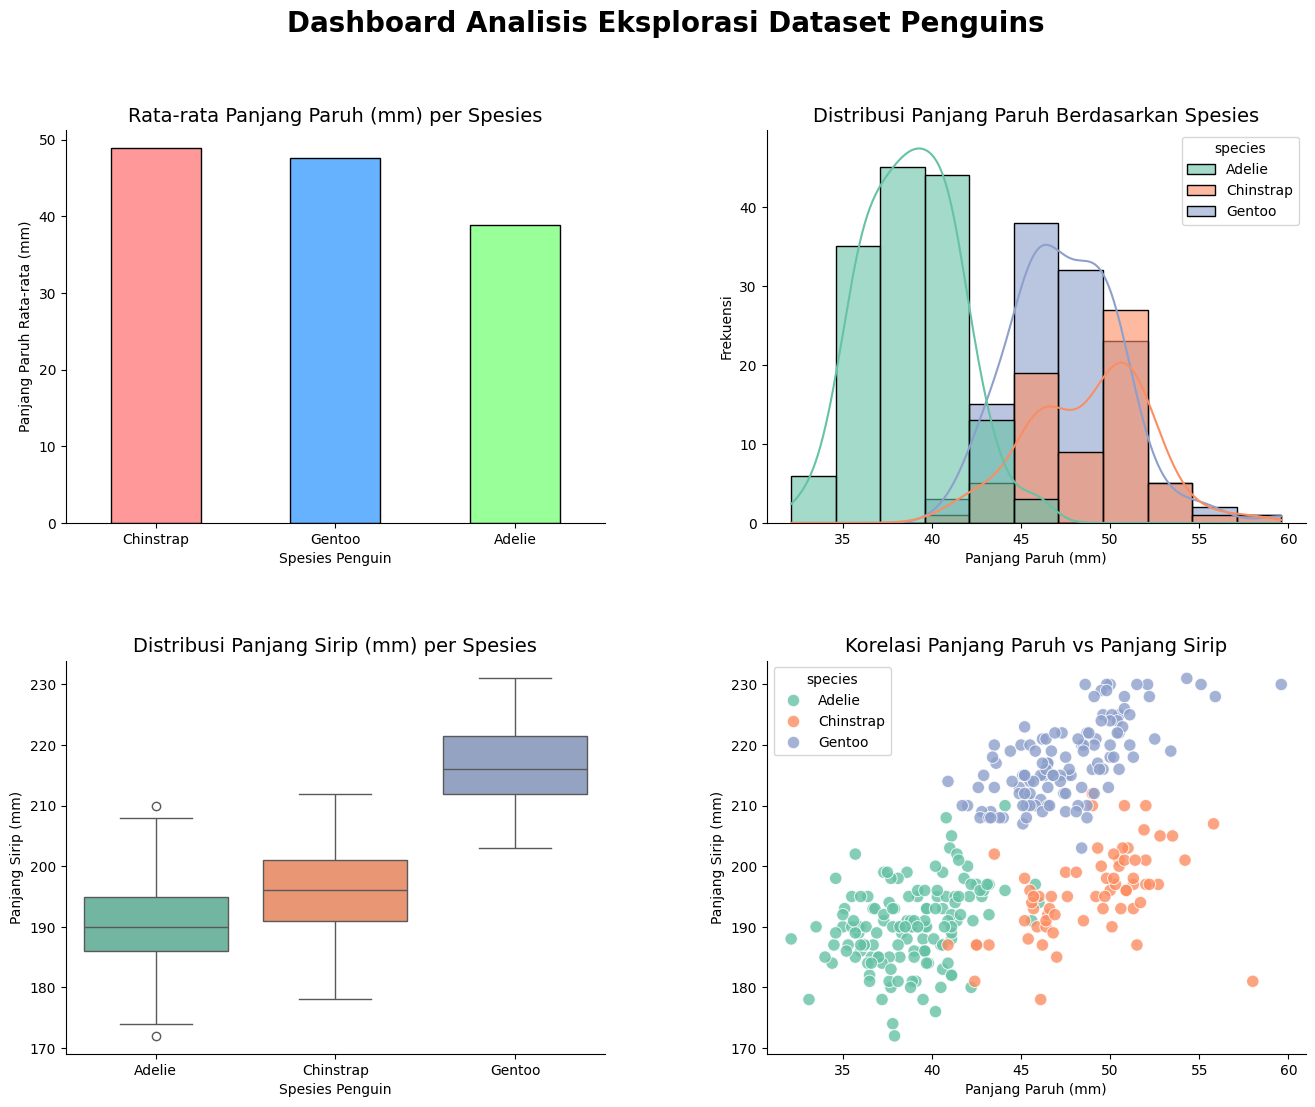

Dashboard berhasil disimpan sebagai 'dashboard_penguins.png'


In [2]:
# 2. SETUP FIGURE LAYOUT (Dashboard 2x2)
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Eksplorasi Dataset Penguins', fontsize=20, fontweight='bold', y=0.98)

# Membuat grid 2 baris x 2 kolom
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ==========================================
# GRAFIK 1: Bar Chart (Rata-rata Panjang Paruh per Spesies)
# ==========================================
avg_bill = df.groupby('species')['bill_length_mm'].mean().sort_values(ascending=False)
avg_bill.plot(kind='bar', ax=ax1, color=['#FF9999', '#66B2FF', '#99FF99'], edgecolor='black')
ax1.set_title('Rata-rata Panjang Paruh (mm) per Spesies', fontsize=14)
ax1.set_xlabel('Spesies Penguin')
ax1.set_ylabel('Panjang Paruh Rata-rata (mm)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False) # Menghilangkan border atas & kanan (Prinsip Estetika)

# ==========================================
# GRAFIK 2: Histogram (Distribusi Panjang Paruh)
# ==========================================
sns.histplot(data=df, x='bill_length_mm', hue='species', kde=True, palette='Set2', ax=ax2, alpha=0.6)
ax2.set_title('Distribusi Panjang Paruh Berdasarkan Spesies', fontsize=14)
ax2.set_xlabel('Panjang Paruh (mm)')
ax2.set_ylabel('Frekuensi')
ax2.spines[['top', 'right']].set_visible(False)

# ==========================================
# GRAFIK 3: Boxplot (Distribusi Panjang Sirip per Spesies)
# ==========================================
sns.boxplot(data=df, x='species', y='flipper_length_mm', palette='Set2', ax=ax3)
ax3.set_title('Distribusi Panjang Sirip (mm) per Spesies', fontsize=14)
ax3.set_xlabel('Spesies Penguin')
ax3.set_ylabel('Panjang Sirip (mm)')
ax3.spines[['top', 'right']].set_visible(False)

# ==========================================
# GRAFIK 4: Scatter Plot (Hubungan Panjang Paruh vs Panjang Sirip)
# ==========================================
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm',
                hue='species', palette='Set2', s=80, alpha=0.8, ax=ax4)
ax4.set_title('Korelasi Panjang Paruh vs Panjang Sirip', fontsize=14)
ax4.set_xlabel('Panjang Paruh (mm)')
ax4.set_ylabel('Panjang Sirip (mm)')
ax4.spines[['top', 'right']].set_visible(False)

# 7. EKSPOR DASHBOARD
plt.savefig('dashboard_penguins.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard berhasil disimpan sebagai 'dashboard_penguins.png'")

1. Bar Chart

What? Grafik ini menampilkan rata-rata panjang paruh (dalam mm) untuk tiga spesies penguin: Adelie, Chinstrap, dan Gentoo. Berdasarkan data, Chinstrap memiliki rata-rata paruh terpanjang (sekitar 48.8 mm), diikuti Gentoo (47.5 mm), dan Adelie terpendek (38.8 mm).

So what? Perbedaan ukuran paruh yang cukup signifikan ini mengindikasikan bahwa morfologi fisik dapat menjadi pembeda utama antar spesies. Chinstrap dan Gentoo memiliki ukuran kepala yang secara umum lebih besar dibanding Adelie.

Now what? Fitur "panjang paruh" sangat potensial digunakan sebagai variabel prediktor utama dalam membangun model klasifikasi mesin (machine learning) untuk membedakan spesies penguin secara otomatis.

2. Histogram

What? Histogram ini menunjukkan distribusi frekuensi panjang paruh, dipisahkan berdasarkan spesies (dengan kurva KDE). Terlihat adanya distribusi bimodal, di mana Adelie mendominasi sisi kiri (35-45 mm), sementara Gentoo mendominasi sisi kanan (45-55 mm), dengan Chinstrap berada di tengah.

So what? Terdapat sedikit tumpang tindih (overlap) antara distribusi panjang paruh spesies Chinstrap dan Adelie, namun spesies Gentoo memiliki distribusi yang sangat terpisah dan konsisten di nilai yang lebih tinggi.

Now what? Perlu dilakukan eksplorasi lebih lanjut apakah faktor lingkungan (seperti pulau asal / island) memengaruhi variasi ukuran paruh pada spesies Chinstrap dan Adelie yang saling tumpang tindih ini.

3. Boxplot

What? Boxplot ini merangkum statistik lima angka untuk panjang sirip (flipper_length_mm) per spesies. Spesies Gentoo memiliki median panjang sirif tertinggi (sekitar 216 mm) dengan sebaran data yang luas, sedangkan Adelie memiliki median terendah (sekitar 190 mm).

So what? Jarak antar kotak (IQR) yang tidak banyak tumpang tindih menunjukkan bahwa panjang sirip adalah fitur yang sangat diskriminatif. Spesies Gentoo secara fisik jauh lebih besar dan memiliki sirip yang lebih panjang untuk berenang, yang sesuai dengan habitatnya.

Now what? Dalam analisis selanjutnya, kita bisa menggabungkan fitur panjang sirip dan panjang paruh untuk membuat aturan keputusan (decision rules) sederhana yang mampu mengklasifikasikan spesies dengan akurasi tinggi.

4. Scatter Plot

What? Scatter plot ini memetakan hubungan antara panjang paruh (sumbu X) dan panjang sirip (sumbu Y), dengan warna yang mewakili spesies. Terlihat korelasi positif yang kuat: semakin panjang paruh, semakin panjang pula siripnya.

So what? Yang paling menarik adalah terbentuknya tiga kluster (pengelompokan) yang sangat jelas berdasarkan warna spesies. Hampir tidak ada titik data yang saling bertumpuk antar spesies yang berbeda, menunjukkan pemisahan yang sangat bersih (clean separation).

Now what? Karena klusternya sangat jelas, algoritma klasifikasi sederhana seperti K-Nearest Neighbors (KNN) atau Decision Tree yang hanya menggunakan dua fitur ini saja sudah diprediksi akan menghasilkan akurasi di atas 95%. Ini akan menjadi langkah selanjutnya yang akan saya coba di proyek modeling.


Kesimpulan: Ada 4 grafik yang dipelajari disini yaitu: Bar Chart, Histogram, Boxplot dan Scatter Plot, dan tema yang digunakan adalah panjang paruh beberapa spesies penguin.